In [ ]:
from utils_functions import *

# Community detection

In [6]:
edges_file = 'graphs/all_edges_consolidated.csv'

G , G_directed = build_graph_from_data(edges_file)
#final_analysis = generate_analysis_report(G , G_directed)
#final_analysis[0].to_csv('graphs/node_metrics_undirected.csv', index=False)
#final_analysis[1].to_csv('graphs/node_metrics_directed.csv', index=False)

final_analysis = (pd.read_csv('graphs/node_metrics_undirected.csv'),
                    pd.read_csv('graphs/node_metrics_directed.csv'))


print("\n--- Top 5 Key Influencers (PageRank) ---")
print(final_analysis[0].sort_values(by='PageRank_Score', ascending=False).head())

Graph initialized: 49994 users, 151771 interactions.

--- Top 5 Key Influencers (PageRank) ---
                   User  Community_ID  Betweenness_Score  PageRank_Score  \
23      ClimateShitpost            55           0.057705        0.006135   
420          idspispopd            19           0.044691        0.005412   
246   livinginahologram             0           0.055989        0.003818   
63   logicalprogressive           146           0.042982        0.003775   
229       suspended_007           146           0.025897        0.003739   

     Coreness_Level  Degree     Network_Role  
23               15    1298  Core (Backbone)  
420              20    1138  Core (Backbone)  
246              19    1350  Core (Backbone)  
63               27    1554  Core (Backbone)  
229              27    1449  Core (Backbone)  


# Dynamic analysys

In [7]:
#weekly_metrics = compute_all_weekly_metrics(edges_file)
weekly_metrics = pd.read_csv('graphs/dynamic_metrics.csv')

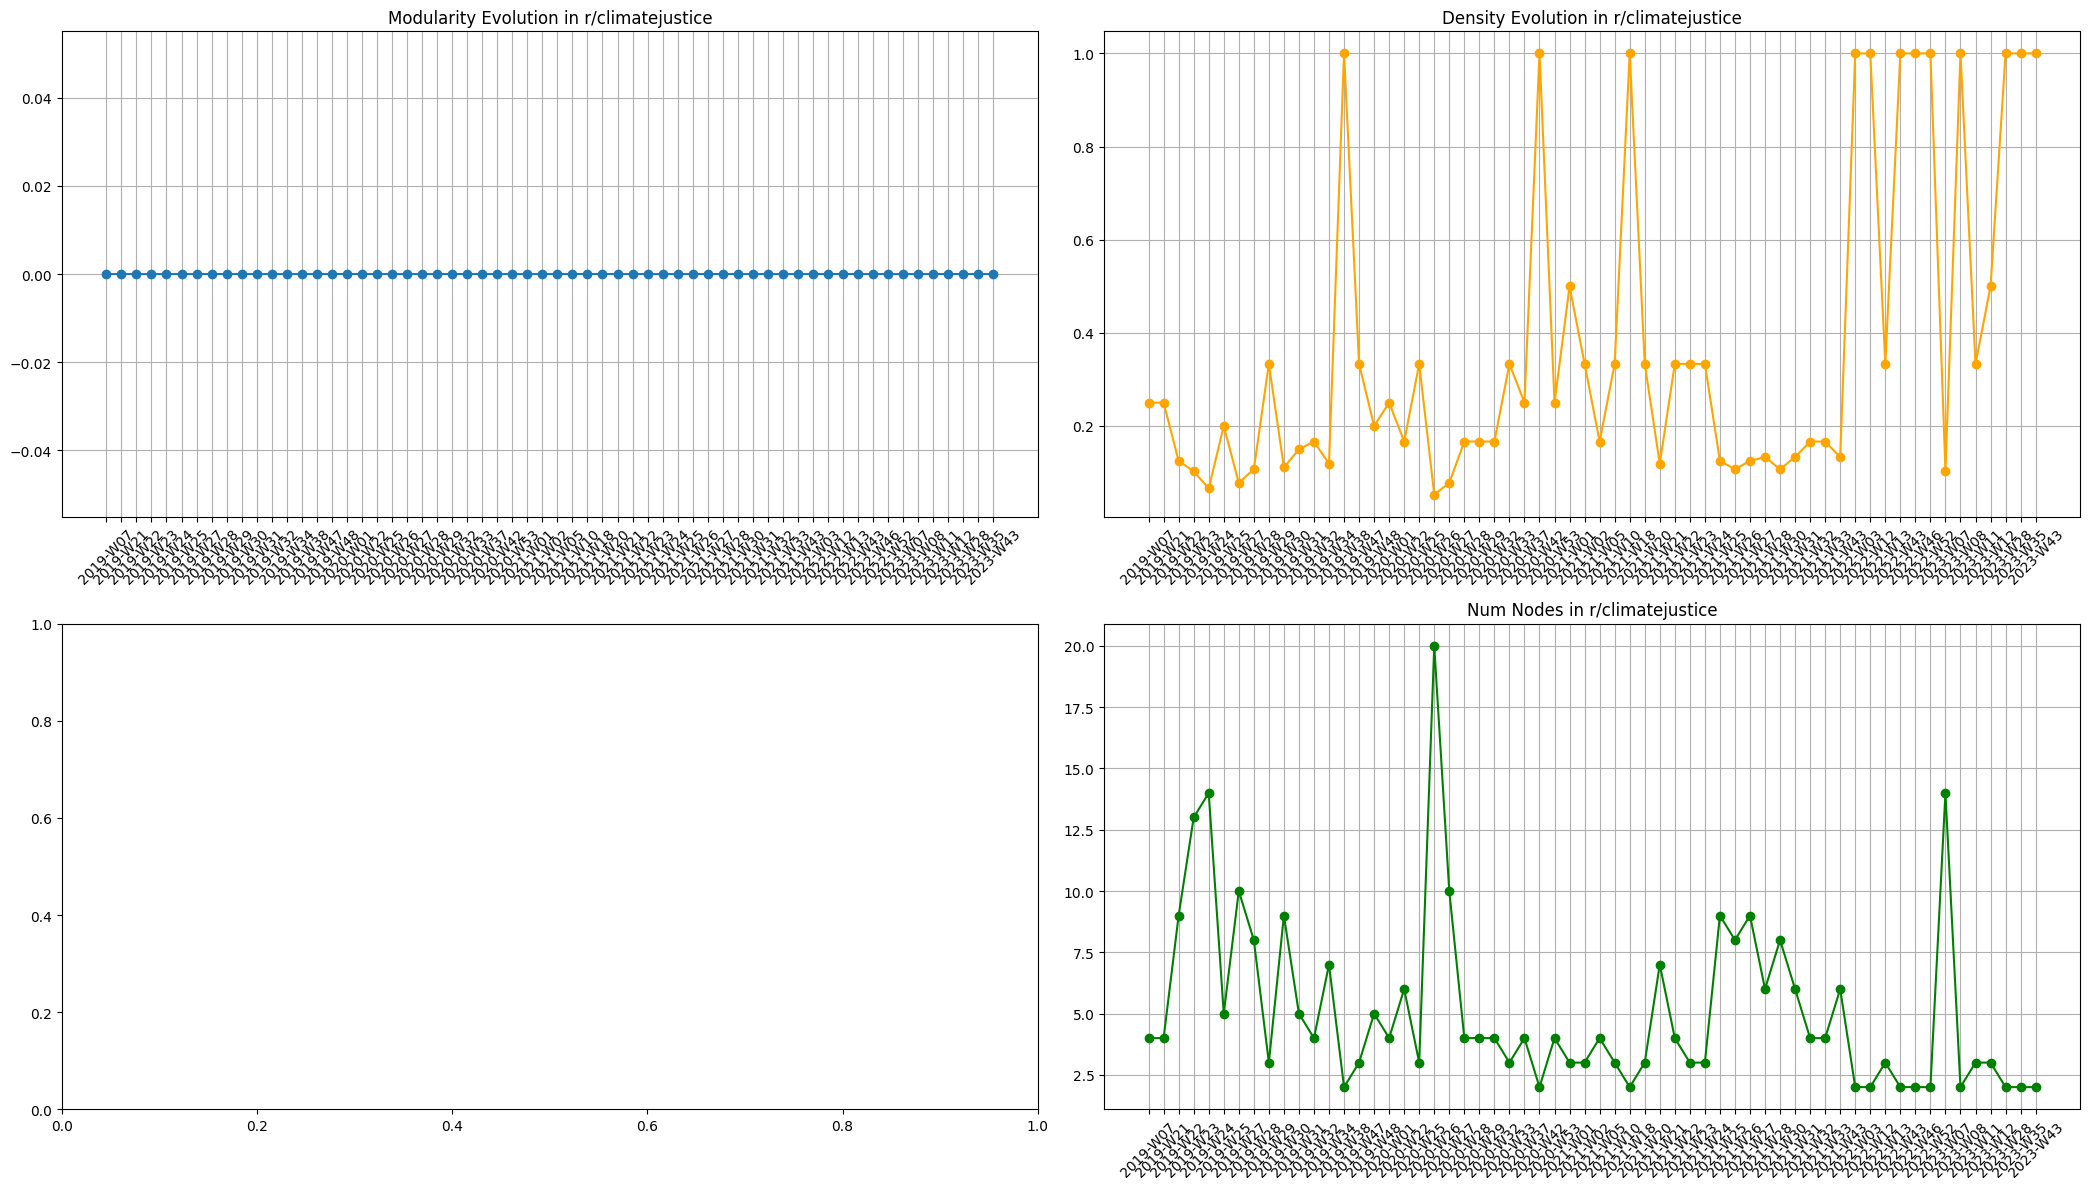

In [8]:
plot_subreddit_metrics(weekly_metrics,"climatejustice")

# Anomaly detection

In [9]:
from utils_2_functions import *

Threshold (99th percentile): 3.32


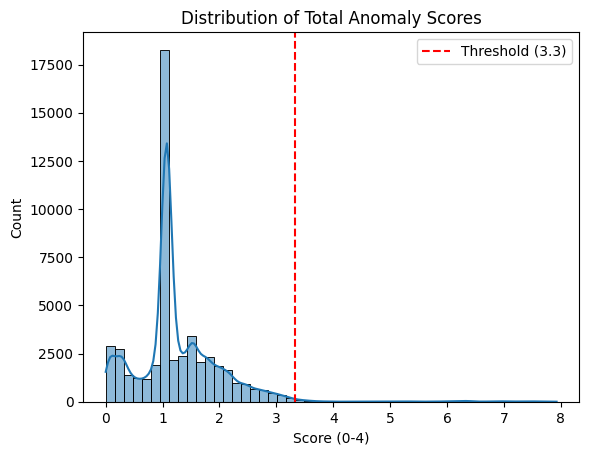

In [10]:
node_metrics = final_analysis[1].copy()
dynamic_metrics = weekly_metrics.copy()

node_metrics = measure_grades(node_metrics, dynamic_metrics)

Total anomalous users flagged: 433


c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=node_metrics, x='Total_Red_Flags', ax=axes[0, 1], palette='Reds')
c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, x='Total_Anomaly_Score', y='User_Str', ax=axes[1, 0], palette='magma')


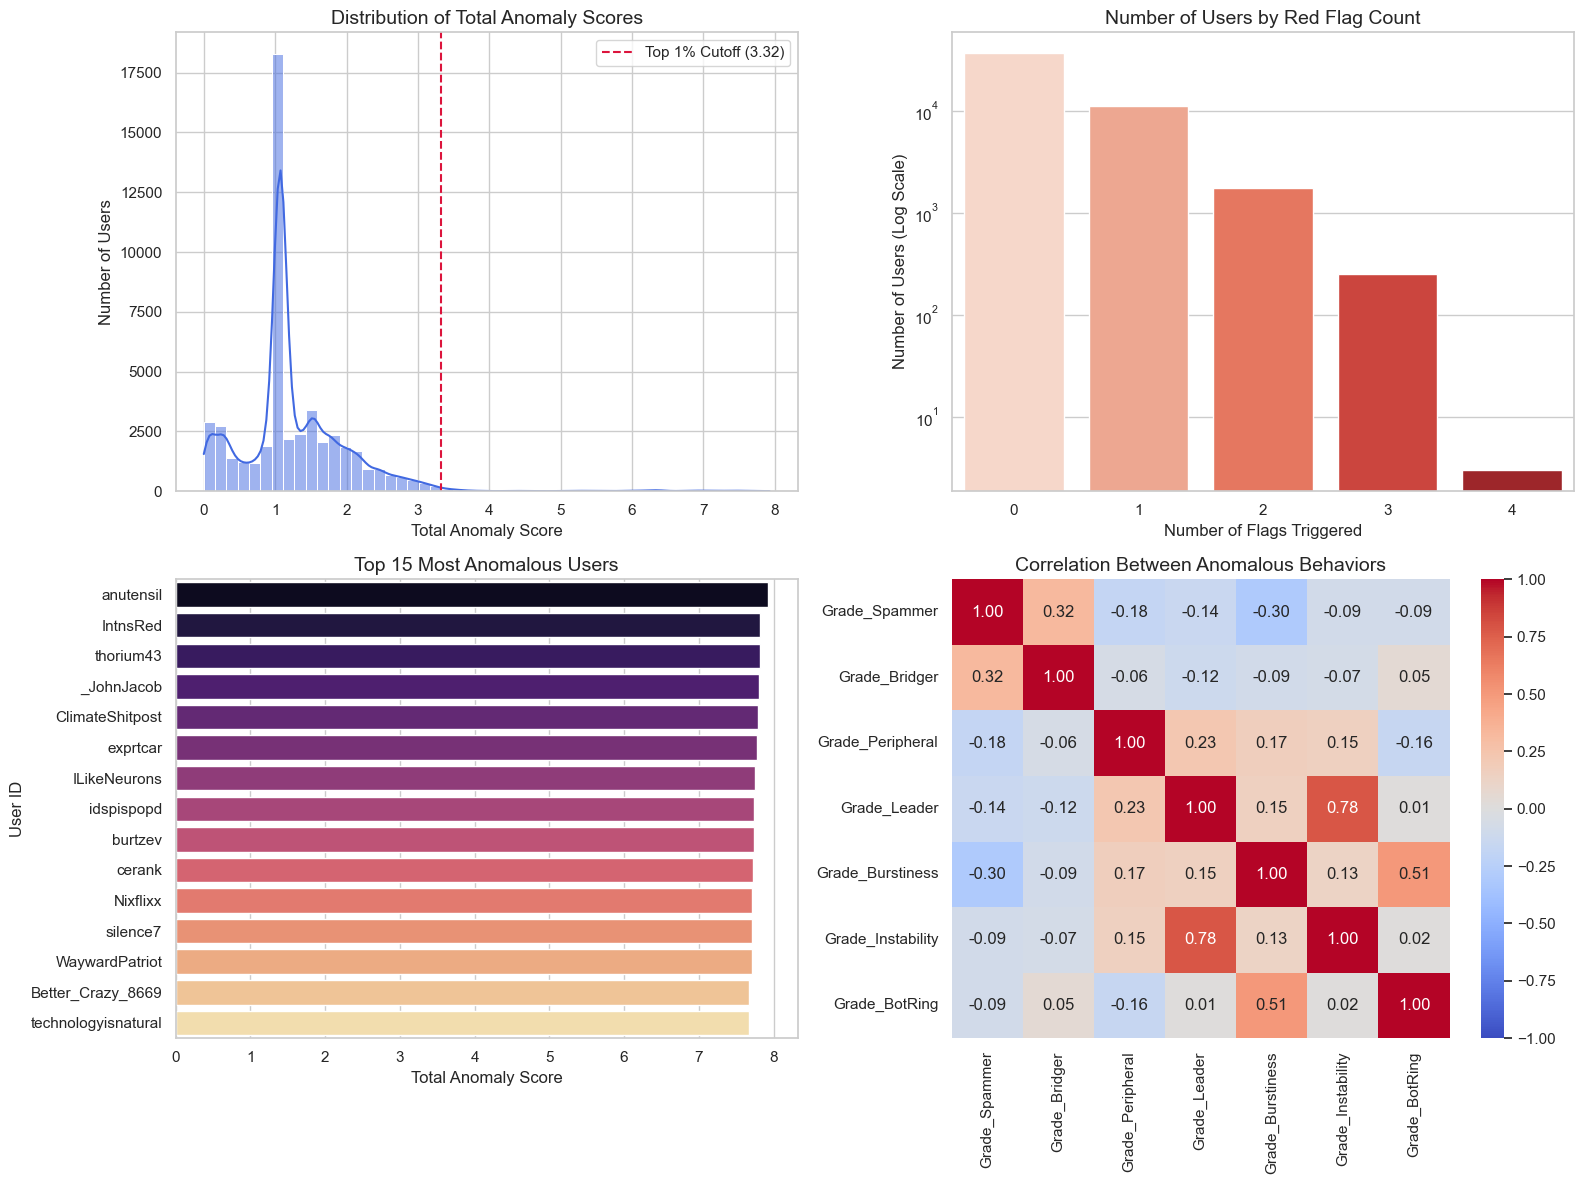

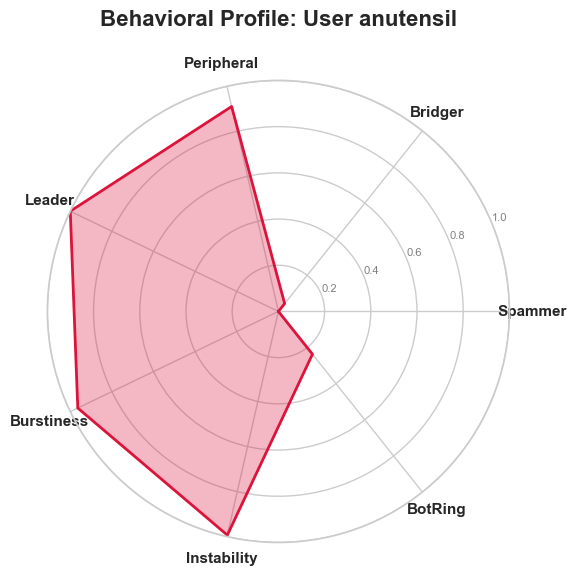

In [11]:
anomalous_users , node_metrics = detect_dynamic_anomalies(node_metrics =  node_metrics,
                                                 global_threshold  = 3.5,
                                                 nb_of_flags = 3)

In [12]:
alerts = detect_anomalies(final_analysis[0])
alert_community_manager(alerts)

🚨 ALERT: 31 suspicious users flagged for DSA review.
------------------------------
                    User                    Type  \
0    Reasonable_doubt_59  Suspicious Core Member   
28            pwrboredom  Suspicious Core Member   
27           Ok_Sea_6214  Suspicious Core Member   
26            beowulftoo  Suspicious Core Member   
25  Revenant_adinfinitum  Suspicious Core Member   
24  Delicious_Summer7839  Suspicious Core Member   
23              jsideris  Suspicious Core Member   
22         Savant_Guarde  Suspicious Core Member   
21               tensigh  Suspicious Core Member   
20  therealdocumentarian  Suspicious Core Member   
19       RealityCheck831  Suspicious Core Member   
18        user4517proton  Suspicious Core Member   
17         WolfieTooting  Suspicious Core Member   
16    TheRealAuthorSarge  Suspicious Core Member   
29          Traveler3141  Suspicious Core Member   
15            Reaper0221  Suspicious Core Member   
13         Moses_Horwitz  Suspic

# Verification

In [ ]:
alert_users = alerts['User'] 
compare_anomalies(anomalous_users , alert_users)

In [16]:
core_list = final_analysis[0][final_analysis[0]['Network_Role'] == 'Core (Backbone)']['User'].tolist()
alert_list = alerts['User'].tolist()
anomalous_list  = anomalous_users
# Prove the core is the "Backbone"
frag_score = test_network_robustness(G, core_list)

community_mapping = detect_communities(G)
# Prove that removing anomalies cleans the network
print("result for alert list : ")
mod_before, mod_after = evaluate_filtering_impact(G, alert_list, community_mapping)
print("\n")
print("result for anomalous list : ")
mod_before, mod_after = evaluate_filtering_impact(G, anomalous_list, community_mapping)


--- Robustness Testing (Structural Pillars) ---
Initial LCC Size: 49547
LCC Size after Core Removal: 15097
Network Fragmentation: 69.53% drop in connectivity.
Community Detection: Found 270 distinct groups.
result for alert list : 

--- Metric Evaluation (Noise Filtering) ---
Original Modularity: 0.6779
Filtered Modularity: 0.6796
Improvement: 0.25%


result for anomalous list : 

--- Metric Evaluation (Noise Filtering) ---
Original Modularity: 0.6779
Filtered Modularity: 0.6744
Improvement: -0.52%


In [21]:
G_clean = test_graph_improvement(G, anomalous_users)

Creating clean graph...

=== BASIC STATS ===
Nodes Removed: 433 (0.87% of network)
Edges Removed: 35823 (23.60% of network)
💡 INSIGHT: Highly disproportionate edge removal. These were likely spammers/hubs!

=== STRUCTURAL HEALTH ===
Density Before: 0.00012
Density After:  0.00009

Assortativity Before: -0.0973
Assortativity After:  -0.0281
💡 INSIGHT: Assortativity increased. The network is behaving more like a natural human network.

Giant Component Before: 49547 nodes (99.1%)
Giant Component After:  42290 nodes (85.3%)

Calculating Average Clustering (This may take a moment)...
Avg Clustering Before: 0.0976
Avg Clustering After:  0.0468
